In [1]:
import pandas
import cv2
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Plot Peta GDP

In [32]:
dta = pandas.read_csv('gdp-per-capita-worldbank.csv')

In [33]:
data2014 = dta[dta['Year'] == 2014]
data2023 = dta[dta['Year'] == 2023]
data1 = data2014[['Entity', 'Code', 'GDP per capita, PPP (constant 2021 international $)']].reset_index(drop=True)
data2 = data2023[['Entity', 'Code', 'GDP per capita, PPP (constant 2021 international $)']].reset_index(drop=True)

In [34]:
da1 = data1['Entity'].tolist()
da2 = data2['Entity'].tolist() 
beda = []
for i in da1:
    if i not in da2:
        beda.append(i)
        
for i in range(len(data1)):
    if data1['Entity'][i] in beda:
        data1 = data1.drop(index=i)

In [35]:
data1 = data1.dropna()
data2 = data2.dropna()
data1 = data1.reset_index(drop=True)
data2 = data2['GDP per capita, PPP (constant 2021 international $)'].reset_index(drop=True)

data = pandas.concat([data1, data2], axis=1)
data.columns = ['Negara', 'Code', '2014', '2023']

In [36]:
hasil = []
for i in range(len(data['2014'])):
    kurang = (data['2023'][i] - data['2014'][i])
    hasil.append(round(kurang, 3))
    
has = pandas.DataFrame(hasil)

In [37]:
gdp_per_capita = pandas.concat([data[['Negara']], has], axis=1)
gdp_per_capita.columns = ['Negara', 'Perbandingan 2014 dengan 2023']

In [38]:
gdp_per_capita

,Negara,Perbandingan 2014 dengan 2023
0,Afghanistan,-1025.518
1,Albania,5264.528
2,Algeria,85.561
3,Andorra,4702.051
4,Angola,-3005.700
...,...,...
187,Vanuatu,-201.983
188,Vietnam,4739.997
189,World,3300.371
190,Zambia,87.907


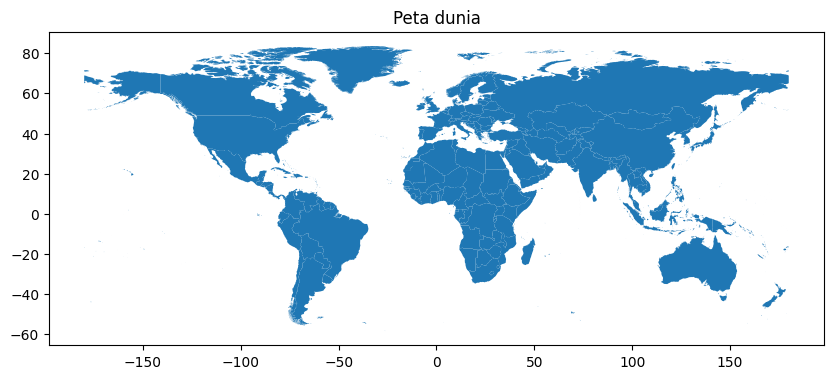

In [39]:
dunia = 'world-administrative-boundaries/world-administrative-boundaries.shp'
mapnya = gpd.read_file(dunia)

mapnya.plot(figsize=(10, 10))
plt.title('Peta dunia')
plt.show()

In [40]:
asean = ['Indonesia', 'Malaysia', 'Thailand', "Lao People's Democratic Republic", 'Laos', 'Cambodia', 'Myanmar', 'Brunei Darussalam', 'Brunei','Philippines', 'Vietnam', 'Singapore']

In [41]:
for i in range(len(gdp_per_capita)):
    if gdp_per_capita['Negara'][i] not in asean:
        gdp_per_capita = gdp_per_capita.drop(index=i)

In [42]:
gdp_asean = gdp_per_capita
gdp_asean = gdp_asean.reset_index(drop=True)

In [43]:
gdp_asean.at[3, 'Negara'] = "Lao People's Democratic Republic"
gdp_asean.at[0, 'Negara'] = 'Brunei Darussalam'
gdp_asean = gdp_asean.dropna()

In [50]:
gdp_asean

,Negara,Perbandingan 2014 dengan 2023
0,Brunei Darussalam,-6482.220
1,Cambodia,1987.859
2,Indonesia,3385.496
3,Lao People's Democratic Republic,2030.944
4,Malaysia,5993.868
5,Myanmar,357.631
6,Philippines,2560.695
7,Singapore,20939.065
8,Thailand,2818.701
9,Vietnam,4739.997


In [ ]:
mean = sum(gdp_asean['Perbandingan 2014 dengan 2023'])/10
mean

3833.2036

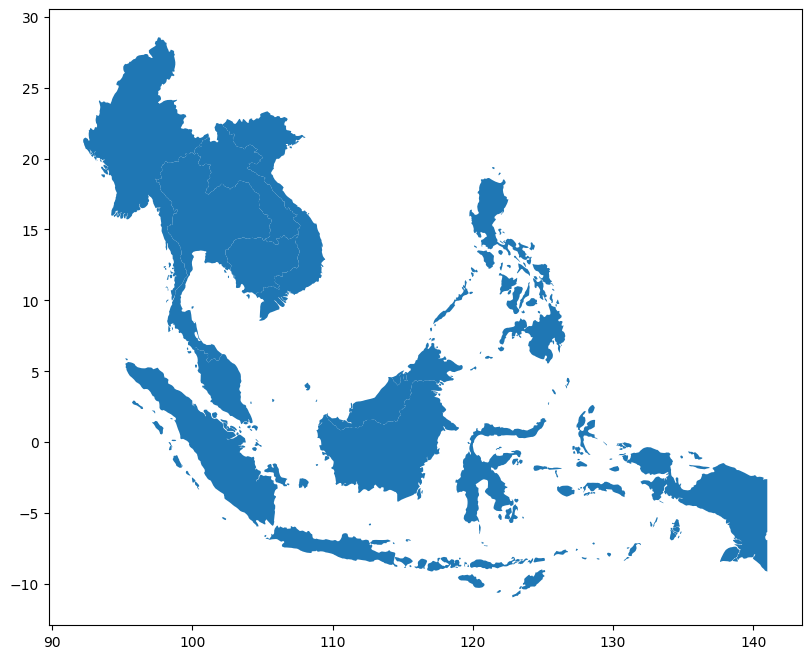

In [45]:
negara1 = mapnya[mapnya['name'].isin(asean)]
negara1.plot(figsize=(10, 8))
plt.show()

In [46]:
mergd = negara1.set_index('name').join(gdp_asean.set_index('Negara'))
mergd

,iso3,status,color_code,continent,region,iso_3166_1_,french_shor,geometry,Perbandingan 2014 dengan 2023
name,,,,,,,,,
Cambodia,KHM,Member State,KHM,Asia,South-Eastern Asia,KH,Cambodge,"POLYGON ((104.44533 10.42274, 104.34608 10.492...",1987.859
Brunei Darussalam,BRN,Member State,BRN,Asia,South-Eastern Asia,BN,Brunéi Darussalam,"MULTIPOLYGON (((115.02913 4.82021, 115.03546 4...",-6482.220
Myanmar,MMR,Member State,MMR,Asia,South-Eastern Asia,MM,Myanmar,"MULTIPOLYGON (((98.15582 9.87666, 98.13602 9.8...",357.631
Lao People's Democratic Republic,LAO,Member State,LAO,Asia,South-Eastern Asia,LA,République démocratique populaire lao,"POLYGON ((102.14074 22.39629, 102.15373 22.384...",2030.944
Philippines,PHL,Member State,PHL,Asia,South-Eastern Asia,PH,Philippines,"MULTIPOLYGON (((120.2536 5.23333, 120.2256 5.1...",2560.695
Indonesia,IDN,Member State,IDN,Asia,South-Eastern Asia,ID,Indonésie,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832...",3385.496
Singapore,SGP,Member State,SGP,Asia,South-Eastern Asia,SG,Singapour,"POLYGON ((103.95997 1.32083, 103.84192 1.25903...",20939.065
Vietnam,VNM,Member State,VNM,Asia,South-Eastern Asia,VN,Viet Nam,"MULTIPOLYGON (((104.08288 10.36486, 104.08663 ...",4739.997
Malaysia,MYS,Member State,MYS,Asia,South-Eastern Asia,MY,Malaisie,"MULTIPOLYGON (((111.41152 2.37639, 111.36804 2...",5993.868


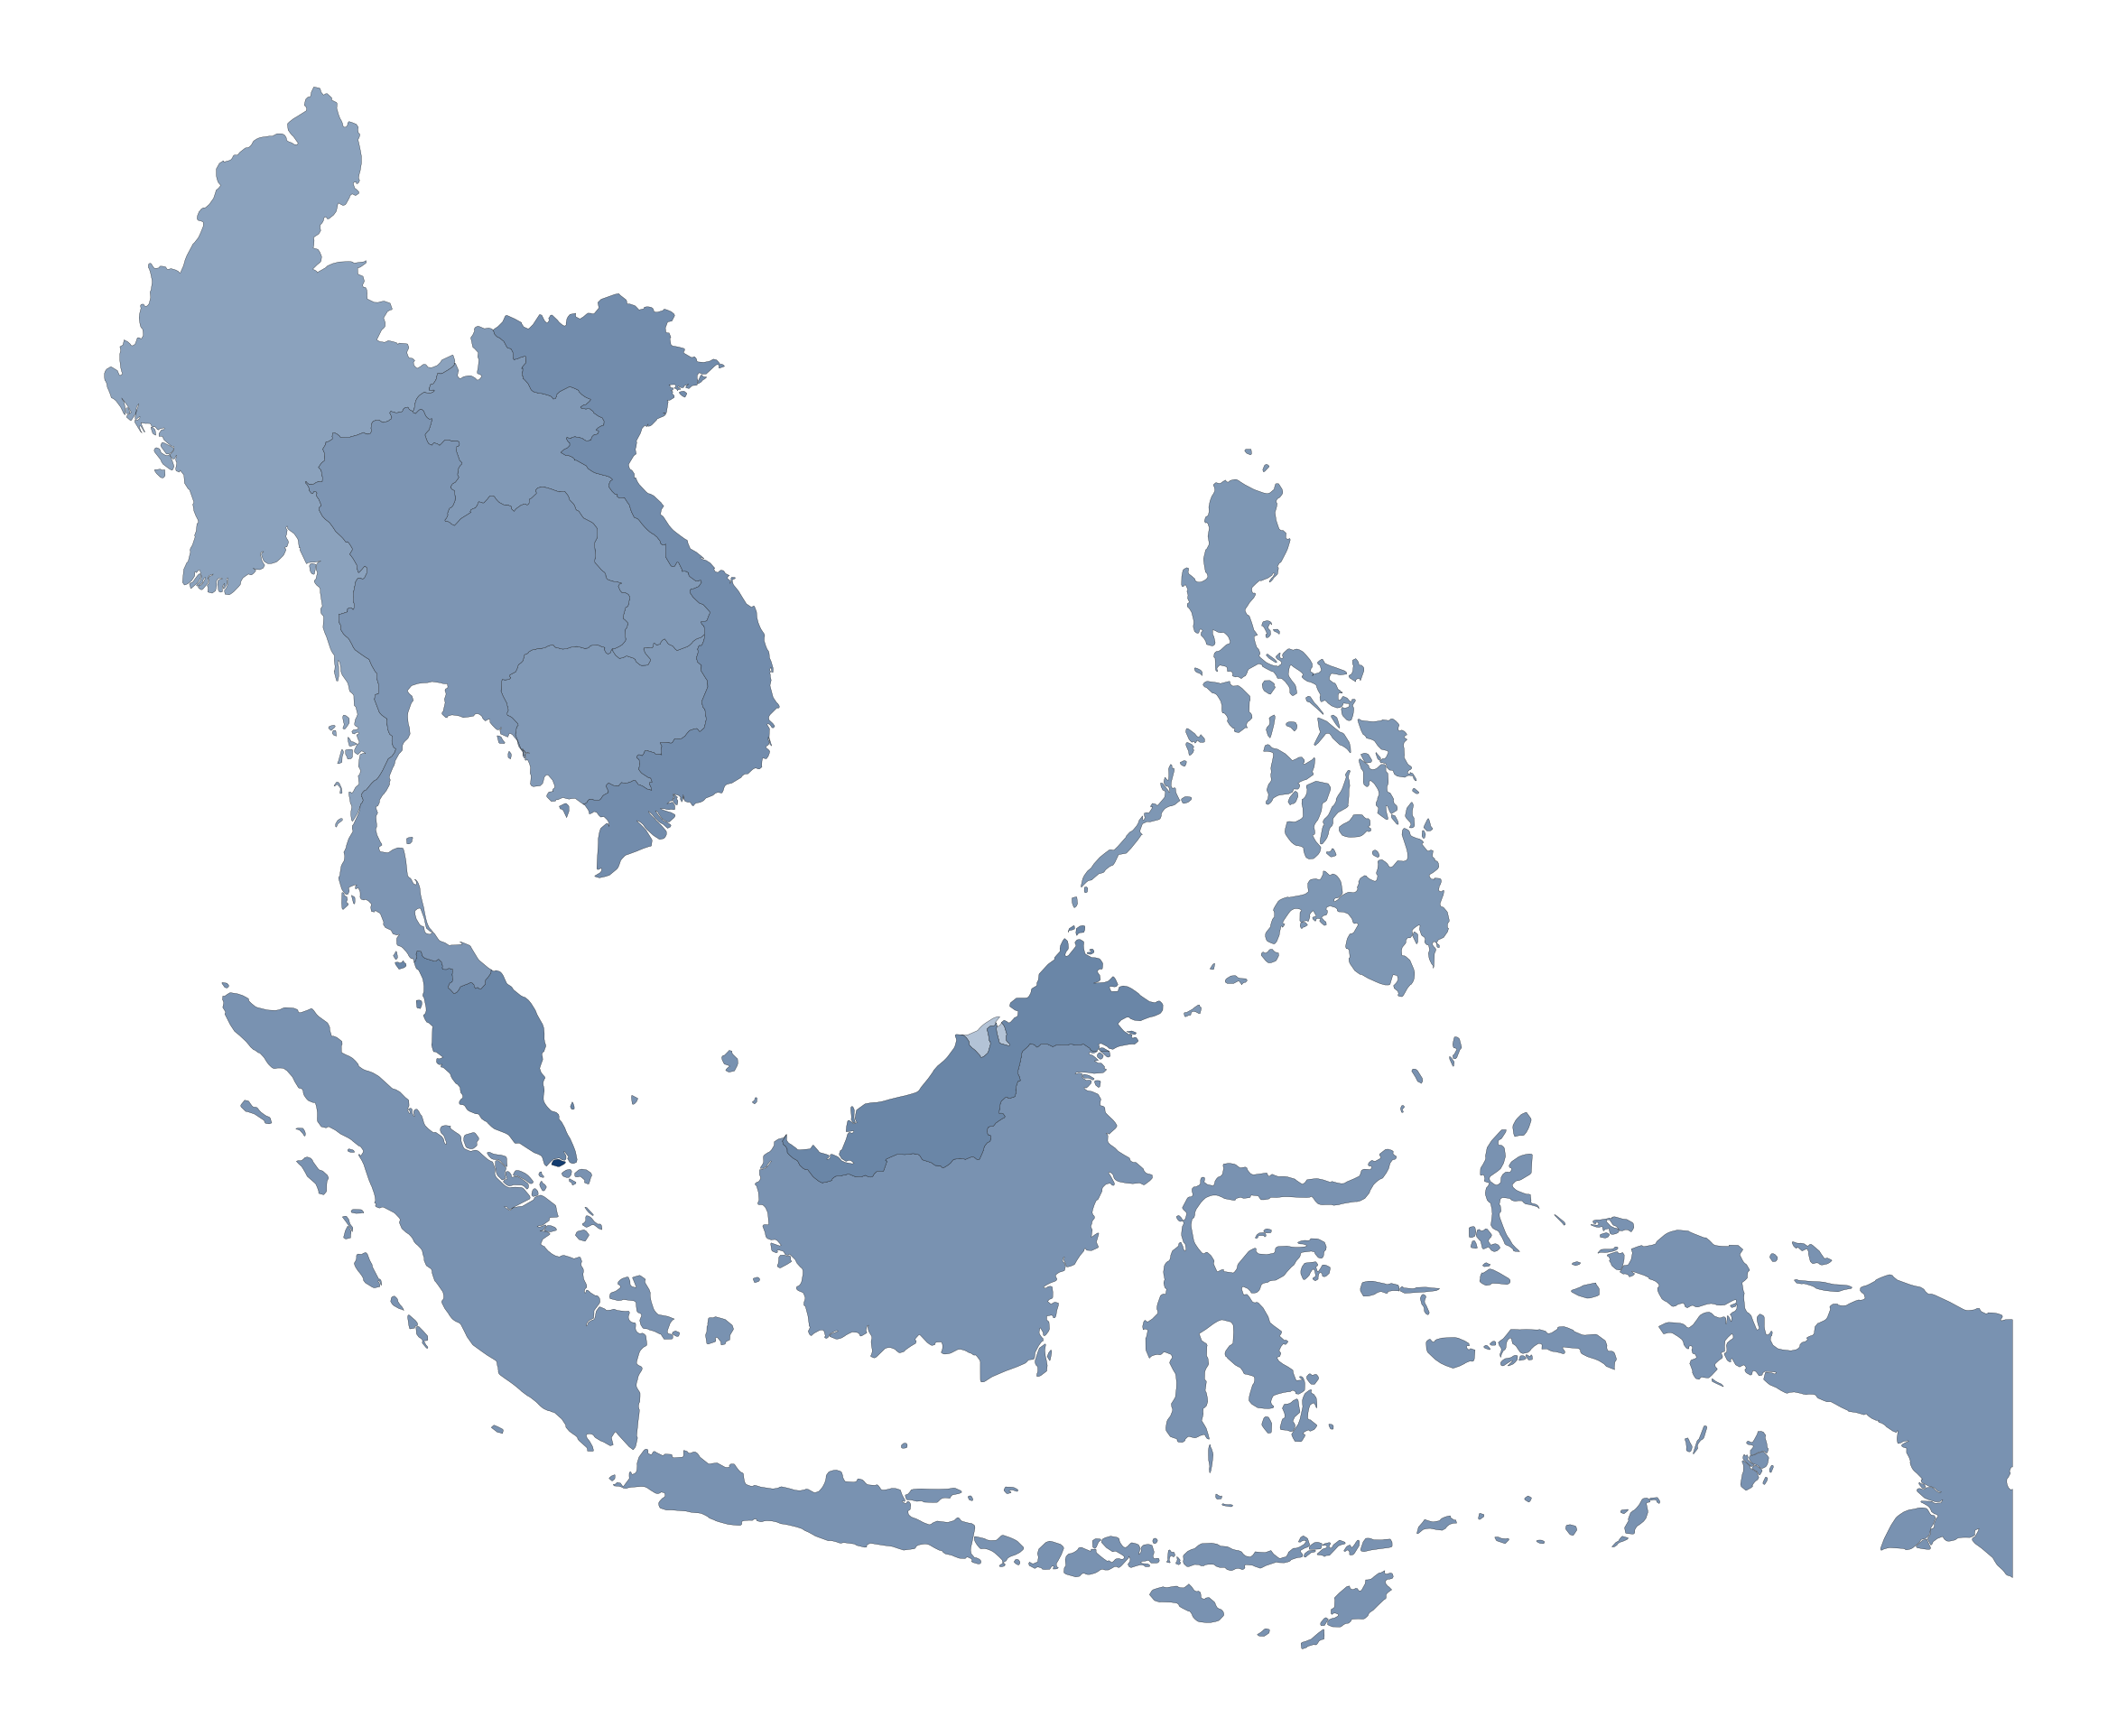

In [47]:
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ['#B3C3D6', '#133C6F'])

fig, ax = plt.subplots(figsize=(30,28))
mergd.plot(column='Perbandingan 2014 dengan 2023',
           cmap=cmap,
           edgecolor='black',
           linewidth=0.2,
           ax=ax)

ax.axis('off')

plt.show()

# Plot IHSG

In [ ]:
minggu = ['2 Desember', '9 Desember', '16 Desember', '23 Desember', '30 Desember', 
         '6 Januari', '13 Januari', '20 Januari', '30 Januari',
         '7 Februari', '14 Februari', '21 Februari', '28 Februari',
         '7 Maret', '14 Maret', '21 Maret', '27 Maret',
         '8 April', '15 April']
ihsg_pada_jam_9 = [7116, 7411, 7292, 7065, 7022, 7114, 7068, 7173, 7051, 6731, 6621, 6809, 6314, 6660, 6551, 6252, 6491, 5912, 6466]

print(len(minggu))
print(len(ihsg_pada_jam_9))

19
19


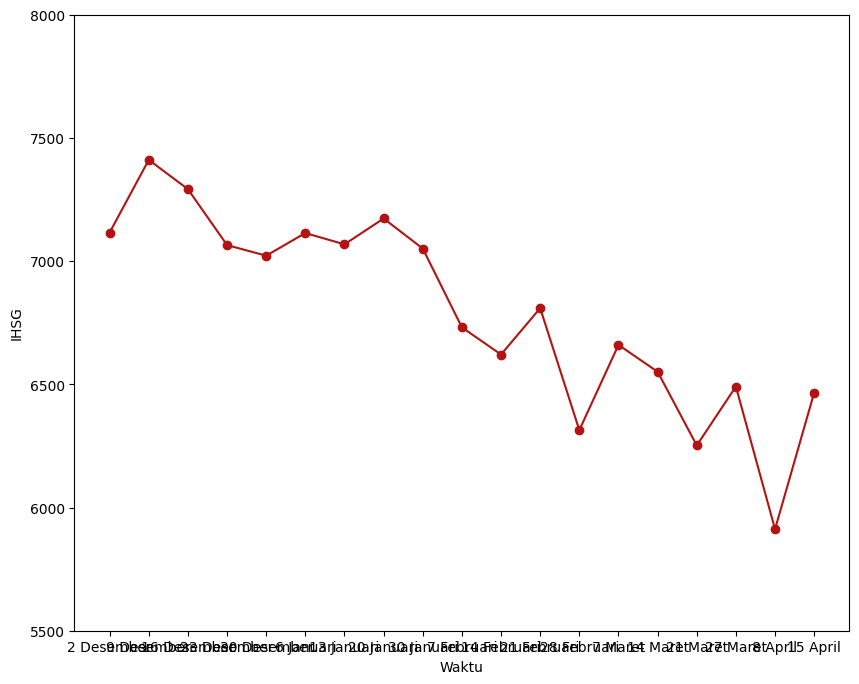

In [18]:
plt.figure(figsize=(10, 8))
plt.plot(minggu, ihsg_pada_jam_9, marker='o', color='#b31312', label='IHSG')

plt.xlabel('Waktu')
plt.ylabel('IHSG')
plt.ylim(5500, 8000)
plt.xticks(minggu)

plt.show()

# Pie Chart Analisi Sentiment

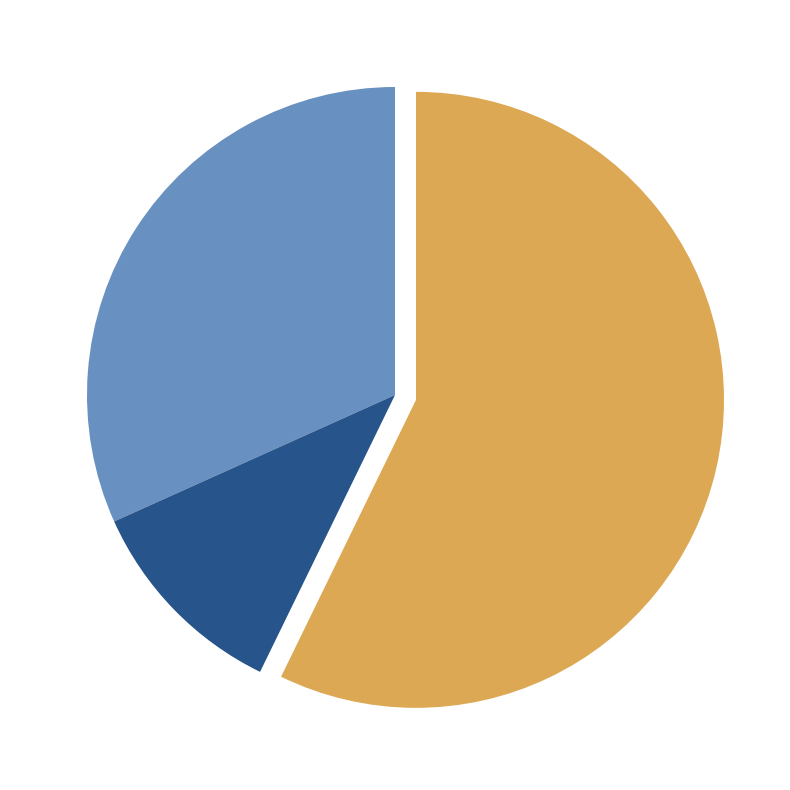

In [30]:
jumlah = [9109, 3171, 16423]
analisis = ["Positif", "Negatif", "Netral"]

warna = ["#6890C0","#27548A", "#DDA853"]

jarak = (0, 0, 0.07)

fig, ax = plt.subplots(figsize=(10, 10))

ax.pie(jumlah, colors=warna, startangle=90, 
       counterclock=True, explode=jarak)

plt.show()